In [1]:
33# ============================================================
# [0] 🔑 투표 기반 분류기 (Voting Classifier) - 앙상블 시작!
# ============================================================
# 💡 앙상블(Ensemble)이란?
# - 여러 모델의 예측을 조합해 더 좋은 결과를 만드는 기법
# - "집단 지성"의 머신러닝 버전
# - 각 모델이 약간 다른 실수를 하면 평균이 더 정확해짐!
#
# 📌 직접 투표 (Hard Voting):
# - 여러 분류기의 예측 중 다수결로 결정
# - 예: LR=1, RF=0, SVC=1 → 다수결 결과: 1
#
# 💡 좋은 앙상블의 조건:
# - 각 분류기가 가능한 한 "독립적"이어야 함
# - 서로 다른 알고리즘 사용 → 다양성 확보!
#
# 여기서는 LogisticRegression, RandomForest, SVC 세 가지 결합
# ============================================================

from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [2]:
# [1] 💡 각 개별 분류기의 정확도 확인
#      - named_estimators_ : {이름: 학습된 모델} 딕셔너리
#      - 보통 개별 정확도가 80~85% 정도 나옴

for name, clf in voting_clf.named_estimators_.items():
  print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [3]:
# [2] 앙상블의 예측 (다수결 결과)

voting_clf.predict(X_test[:1])

array([1])

In [4]:
# [3] 💡 개별 분류기들의 예측 비교
#      각 모델이 어떻게 예측했는지 확인 가능
#      → 의견이 갈릴 수도, 일치할 수도 있음

[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

In [5]:
# [4] 💡 앙상블의 정확도 - 보통 개별 모델들보다 높음!
#       이게 앙상블의 위력 ⭐

voting_clf.score(X_test, y_test)

0.912

In [6]:
# ============================================================
# [5] 🔑 간접 투표 (Soft Voting) - 보통 더 좋음!
# ============================================================
# 💡 Hard Voting vs Soft Voting:
# - Hard: 각 분류기의 예측 클래스로 다수결
# - Soft: 각 분류기의 확률을 평균 → 가장 높은 확률 클래스 선택
#
# 💡 Soft가 보통 더 좋은 이유:
# - "확신 있는 표"에 더 많은 가중치를 부여
# - 예: "70% 확신"보다 "99% 확신"이 더 중요하게 반영
#
# ⚠️ 주의: SVC는 기본적으로 확률을 반환 안 함
#         → probability=True 필수!
# ============================================================

voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

In [7]:
# ============================================================
# [6] 🔑 배깅(Bagging) - Bootstrap Aggregating
# ============================================================
# 💡 배깅이란?
# - 같은 알고리즘을 사용하되, 훈련 데이터를 다르게 샘플링
# - bootstrap=True: 중복 허용 샘플링 (배깅)
# - bootstrap=False: 중복 없이 샘플링 (페이스팅)
#
# 📌 매개변수:
# - DecisionTreeClassifier(): 기본 분류기 (트리들의 모음 = 숲!)
# - n_estimators=500: 500개의 트리 사용
# - max_samples=100: 각 트리는 100개 샘플로 학습
# - n_jobs=-1: 모든 CPU 코어 사용 (병렬 처리)
#
# 💡 왜 효과적?
# - 각 트리가 다른 데이터로 학습 → 다양성 확보
# - 평균을 내면 분산(variance) 감소 → 과대적합 완화
# ============================================================

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

In [8]:
# ============================================================
# [7] 🔑 OOB(Out-of-Bag) 평가 - 무료 검증 세트!
# ============================================================
# 💡 OOB란?
# - 부트스트랩 샘플링 시 평균 약 37%의 샘플은 안 뽑힘
# - 이 "남은 샘플"로 모델 성능 평가 가능
# - 별도의 검증 세트 없이도 평가 가능!
#
# 📌 oob_score=True: OOB 평가 활성화
# - oob_score_: OOB 정확도 (검증 세트 점수와 비슷한 값)
#
# 💡 장점: 교차 검증 없이도 성능 추정 → 시간 절약!
# ============================================================

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [9]:
# [8] 💡 OOB 점수와 테스트 점수 비교
#       두 값이 비슷하게 나오면 OOB가 좋은 추정치라는 뜻 ✅

from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

In [10]:
# [9] 💡 oob_decision_function_ - OOB 샘플의 클래스별 확률
#       앞 3개 샘플의 [클래스 0 확률, 클래스 1 확률] 확인

bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

In [11]:
# ============================================================
# [10] 🔑 랜덤 포레스트 (Random Forest) - 가장 인기있는 앙상블!
# ============================================================
# 💡 랜덤 포레스트 = 배깅 + 결정 트리 + 특성 무작위 선택
#
# 📌 일반 배깅과의 차이:
# - 일반 배깅: 모든 특성을 고려해 최적 분할 찾음
# - 랜덤 포레스트: 각 노드에서 무작위 특성 일부만 고려
#   → 더 다양한 트리 생성 → 더 나은 일반화
#
# 📌 매개변수:
# - n_estimators=500: 500개의 트리
# - max_leaf_nodes=16: 각 트리의 최대 리프 노드 (규제)
# - n_jobs=-1: 병렬 처리
#
# 💡 왜 인기있나?
# - 거의 튜닝 없이도 좋은 성능
# - 과대적합 잘 안 됨
# - 특성 중요도 제공
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

In [12]:
# ============================================================
# [11] 💡 랜덤 포레스트는 본질적으로 BaggingClassifier + 특별한 트리
# ============================================================
# 이 코드는 RandomForestClassifier와 거의 동등한 BaggingClassifier
# - max_features="sqrt": √n_features 만큼 무작위 선택 (랜덤 포레스트와 동일)
# - max_leaf_nodes=16: 동일한 규제
#
# 즉 RandomForestClassifier는 이 설정의 편의 wrapper!
# ============================================================

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

In [13]:
# [12] 💡 BaggingClassifier(트리)와 RandomForestClassifier 결과 동등성 확인
#       np.all(...): 모든 예측이 동일한지 검사 → True 반환되면 동등!

import numpy as np

bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
np.all(y_pred_bag == y_pred_rf)

np.True_

In [14]:
# ============================================================
# [13] 🔑 특성 중요도 (Feature Importance)
# ============================================================
# 💡 랜덤 포레스트의 강력한 부가 기능
# - 각 특성이 트리에서 분할 기준으로 얼마나 자주, 효과적으로 쓰였는지
# - 0~1 사이 값, 합이 1
#
# 👁️ Iris 데이터에서:
# - petal length, petal width가 가장 중요
# - sepal 특성들은 덜 중요
#
# 💡 특성 선택, 모델 해석에 유용!
# ============================================================

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
  print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


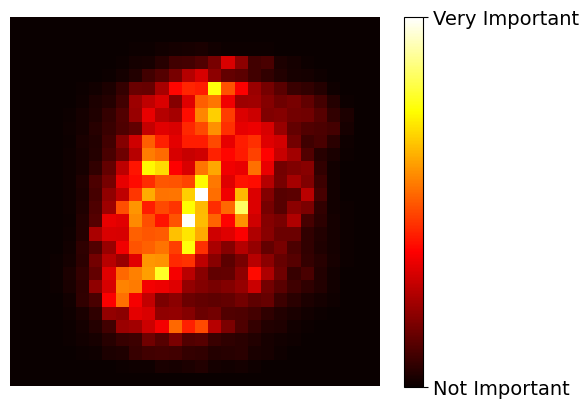

In [15]:
# ============================================================
# [14] 💡 MNIST 픽셀 중요도 시각화 - 멋진 응용!
# ============================================================
# 28×28 = 784개 픽셀의 중요도를 히트맵으로 표현
#
# 👁️ 예상되는 결과:
# - 이미지 중앙 부분이 매우 중요 (숫자가 그려지는 곳)
# - 가장자리는 거의 0 (대부분 빈 픽셀)
# - "어디를 봐야 하는지" 모델이 알려줌!
#
# 💡 이런 시각화는 모델 해석과 디버깅에 유용
# ============================================================

import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True,
                                as_frame=False, parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not Important', 'Very Important'], fontsize=14)
plt.axis("off")
plt.show()

In [16]:
# ============================================================
# [15] 🔑 부스팅 시작! - AdaBoost (적응형 부스팅)
# ============================================================
# 💡 부스팅(Boosting)이란?
# - 약한 학습기들을 "순차적"으로 학습
# - 이전 모델이 틀린 샘플에 가중치를 더 줘서 다음 모델 학습
# - 점점 더 어려운 문제를 푸는 형태
#
# 💡 배깅 vs 부스팅:
# - 배깅: 병렬 학습 (독립적), 분산 감소
# - 부스팅: 순차 학습 (의존적), 편향 감소
#
# 📌 매개변수:
# - DecisionTreeClassifier(max_depth=1): 약한 학습기 (스텀프!)
# - n_estimators=30: 30개의 약한 학습기
# - learning_rate=0.5: 각 학습기의 기여도 (작을수록 안정, 큰 n_estimators 필요)
# ============================================================

from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30,
    learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=30, random_state=42)

In [17]:
# ============================================================
# [16] 🔑 그래디언트 부스팅 직접 구현 (1단계) - 첫 번째 트리
# ============================================================
# 💡 그래디언트 부스팅(GBRT)의 핵심 아이디어:
# "이전 모델의 잔차(residual)에 새 모델을 학습"
#
# 📌 1단계:
# - 데이터 생성: y = 3x² + 노이즈 (2차 함수 형태)
# - 첫 번째 트리: 원본 y에 학습
# - 결과: 대략적인 패턴 학습 (완벽하진 않음)
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeRegressor
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [18]:
# ============================================================
# [17] 💡 그래디언트 부스팅 (2단계) - 첫 트리의 잔차에 학습
# ============================================================
# y2 = y - tree_reg1.predict(X)
#     ↑ 잔차(residual): 첫 트리가 못 맞춘 부분
#
# tree_reg2: 이 잔차를 예측하도록 학습
# → 첫 트리의 실수를 보완하는 역할
# ============================================================

y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=43)

In [19]:
# ============================================================
# [18] 💡 그래디언트 부스팅 (3단계) - 두 번째 트리의 잔차에 학습
# ============================================================
# y3 = y2 - tree_reg2.predict(X)
#     ↑ 두 번째 트리도 못 맞춘 부분
#
# tree_reg3: 이 남은 잔차를 학습
# → 점점 정교해짐!
# ============================================================

y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2, random_state=44)

In [20]:
# ============================================================
# [19] 🎯 모든 트리의 예측을 합산 = 최종 예측
# ============================================================
# 💡 그래디언트 부스팅의 최종 예측:
# y_pred = tree1(x) + tree2(x) + tree3(x) + ...
#
# 각 트리가 이전 트리의 실수를 보정하므로 합치면 정확한 예측!
# ============================================================

X_new = np.array([[-0.4], [0.], [0.5]])
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.48779682, 0.12356613, 0.52856846])

In [21]:
# ============================================================
# [20] 🔑 사이킷런의 GradientBoostingRegressor - 자동화!
# ============================================================
# 💡 [16~19]에서 직접 했던 작업을 한 줄로:
#
# 📌 매개변수:
# - max_depth=2: 약한 학습기들의 깊이
# - n_estimators=3: 트리 3개 사용 (위와 동일)
# - learning_rate=1.0: 각 트리의 기여도 (1.0 = 그대로 더함)
#   * 작은 learning_rate + 많은 n_estimators = 더 안정적
#   * 이게 "축소(shrinkage)" 규제!
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3,
                                  learning_rate=1.0, random_state=42)
gbrt.fit(X, y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3,
                          random_state=42)

In [22]:
# ============================================================
# [21] 💡 조기 종료(early stopping) 자동 적용
# ============================================================
# 📌 핵심 매개변수:
# - learning_rate=0.05: 작은 학습률 (안정적 학습)
# - n_estimators=500: 최대 500개 트리
# - n_iter_no_change=10: 검증 점수가 10번 개선 없으면 중단!
#
# 💡 효과:
# - 자동으로 최적 트리 개수를 찾음
# - 과대적합 방지
# - 시간 절약
# ============================================================

gbrt_best = GradientBoostingRegressor(
    max_depth=2, learning_rate=0.05, n_estimators=500,
    n_iter_no_change=10, random_state=42)
gbrt_best.fit(X, y)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=500,
                          n_iter_no_change=10, random_state=42)

In [23]:
# [22] 💡 실제로 사용된 트리 개수 확인
#       n_iter_no_change=10 덕에 500개 다 안 쓰고 조기 종료됐을 것

gbrt_best.n_estimators_

92

In [24]:
# [23] 💡 캘리포니아 주택 데이터 로드 - HistGradientBoosting 실습용

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import numpy as np

def load_housing_data():
  tarball_path = Path("datasets/housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url="https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
  with tarfile.open(tarball_path) as housing_tarball:
    housing_tarball.extractall(path="datasets")
  return pd.read_csv(Path("datasets/housing/housing.csv"))

housing=load_housing_data()

/tmp/ipykernel_2995/2511324590.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [25]:
# [24] 훈련/테스트 분할 + 특성/레이블 분리

housing = load_housing_data()

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

housing_labels = train_set["median_house_value"]
housing = train_set.drop("median_house_value", axis=1)

/tmp/ipykernel_2995/2511324590.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [26]:
# ============================================================
# [25] 🔑 HistGradientBoostingRegressor - 매우 빠른 부스팅!
# ============================================================
# 💡 특징:
# - 히스토그램 기반: 특성을 256개 구간으로 묶어 빠르게 분할
# - 큰 데이터셋에서 일반 GBRT보다 훨씬 빠름!
# - 범주형 특성을 직접 처리 (categorical_features 매개변수)
# - LightGBM, XGBoost와 비슷한 알고리즘
#
# 📌 파이프라인:
# - OrdinalEncoder: ocean_proximity 같은 범주형을 정수로
# - remainder="passthrough": 나머지 열은 그대로
# - categorical_features=[0]: 0번 열이 범주형이라고 알려줌
#
# 💡 왜 이게 강력해?
# - 빠르고, 정확하고, 결측치 자동 처리
# - 실전 머신러닝 대회에서 자주 우승하는 알고리즘 계열
# ============================================================

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

hgb_reg = make_pipeline(
    make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
                            remainder="passthrough"),
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)
hgb_reg.fit(housing, housing_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['ocean_proximity'])])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(categorical_features=[0],
                                               random_state=42))])

In [27]:
# [26] 💡 교차 검증으로 RMSE 평가
#       - 평균 RMSE가 보통 $47,000 정도 (랜덤 포레스트와 비슷하거나 더 좋음)
#       - describe(): 평균, 표준편차, 최소/최대 등 한번에 확인

from sklearn.model_selection import cross_val_score

hgb_rmses = -cross_val_score(hgb_reg, housing, housing_labels,
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(hgb_rmses).describe()

,0
count,10.000000
mean,47613.307194
std,1295.422509
min,44963.213061
25%,47001.233485
50%,48000.963564
75%,48488.093243
max,49176.368465


In [28]:
# ============================================================
# [27] 🔑 스태킹(Stacking) - 가장 진보된 앙상블!
# ============================================================
# 💡 스태킹이란?
# - 여러 모델의 예측을 또 다른 모델("메타 모델")이 학습해서 결합
# - "예측을 예측하는" 모델
#
# 📌 구조:
# - estimators: 1단계 모델들 (LR, RF, SVC)
# - final_estimator: 2단계 메타 모델 (RandomForest)
# - cv=5: 5-폴드로 교차 검증해 메타 모델 학습 데이터 생성
#
# 💡 투표 vs 스태킹:
# - 투표: 단순 다수결 / 평균
# - 스태킹: 메타 모델이 "어떤 모델을 더 신뢰할지" 학습!
#
# 보통 스태킹이 단순 투표보다 더 좋은 성능 (단, 시간이 더 걸림)
# ============================================================

from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv=5
)
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('svc', SVC(probability=True, random_state=42))],
                   final_estimator=RandomForestClassifier(random_state=43))

In [29]:
# [28] 스태킹 모델의 정확도 - 보통 단순 투표보다 약간 더 좋음

stacking_clf.score(X_test, y_test)

0.928

In [30]:
# ============================================================
# [29] 🎓 연습문제: MNIST로 앙상블 종합 실습
# ============================================================
# 💡 데이터를 3분할:
# - 훈련: 50,000개 (개별 모델 학습용)
# - 검증: 10,000개 (앙상블 성능 확인용)
# - 테스트: 10,000개 (최종 평가)
#
# 💡 왜 3분할?
# - 앙상블 모델 선택은 검증 세트에서
# - 진짜 일반화 성능은 테스트 세트에서
# ============================================================

X_train, y_train = X_mnist[:50_000], y_mnist[:50_000]
X_valid, y_valid = X_mnist[50_000:60_000], y_mnist[50_000:60_000]
X_test, y_test = X_mnist[60_000:], y_mnist[60_000:]

In [31]:
# ============================================================
# [30] 💡 4가지 다양한 분류기 준비 - 다양성이 핵심!
# ============================================================
# - RandomForestClassifier: 트리 기반 앙상블
# - ExtraTreesClassifier: 더 무작위한 랜덤 포레스트 (Extremely Randomized Trees)
# - LinearSVC: 선형 SVM
# - MLPClassifier: 신경망 (Multi-Layer Perceptron)
#
# 💡 4가지 다른 알고리즘 → 서로 다른 실수 → 앙상블 효과 극대화!
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
svm_clf = LinearSVC(max_iter=100, tol=20, dual=True, random_state=42)
mlp_clf = MLPClassifier(random_state=42)

In [32]:
# [31] 💡 각 모델 학습 (시간 좀 걸림 - MNIST는 큰 데이터)

estimators = [random_forest_clf, extra_trees_clf, svm_clf, mlp_clf]
for estimator in estimators:
  print("훈련 모델:", estimator)
  estimator.fit(X_train, y_train)

훈련 모델: RandomForestClassifier(random_state=42)
훈련 모델: ExtraTreesClassifier(random_state=42)
훈련 모델: LinearSVC(dual=True, max_iter=100, random_state=42, tol=20)
훈련 모델: MLPClassifier(random_state=42)


In [33]:
# [32] 💡 검증 세트에서 각 모델의 정확도
#       보통 RF, ExtraTrees, MLP > 90%, LinearSVC는 더 낮음

[estimator.score(X_valid, y_valid) for estimator in estimators]

[0.9736, 0.9743, 0.8662, 0.9613]

In [34]:
# ============================================================
# [33] 🔑 4개 모델로 VotingClassifier 만들기
# ============================================================
# - 단순 다수결로 결합
# - 보통 개별 최고 모델보다 더 좋은 성능 ✨
# - voting_clf.fit(): 모든 추정기를 다시 학습 (이미 학습된 거 무시)
# ============================================================

from sklearn.ensemble import VotingClassifier

named_estimators = [
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf),
    ("svm_clf", svm_clf),
    ("mlp_clf", mlp_clf),
]

voting_clf = VotingClassifier(named_estimators)
voting_clf.fit(X_train, y_train)

voting_clf.score(X_valid, y_valid)

0.975

In [35]:
# [34] 💡 테스트 세트에서 앙상블 성능 - 일반화 성능 확인

voting_clf.score(X_test, y_test)

0.9712

In [36]:
# [35] 💡 개별 분류기들의 테스트 정확도 비교
#       앙상블이 개별 최고 모델보다 더 좋은지 확인

# 개별 분류기의 테스트 성능
[estimator.score(X_test, y_test.astype(np.int64))
for estimator in voting_clf.estimators_]

[0.968, 0.9703, 0.8612, 0.9618]

In [37]:
# ============================================================
# [36] 💡 약한 모델 제거하기 - 앙상블 정제
# ============================================================
# LinearSVC 성능이 너무 낮으면 빼버리는 게 나을 수도!
# - named_estimators_.pop(): 이름 기반으로 제거
# - estimators_.remove(): 학습된 모델 리스트에서도 제거
#
# 💡 교훈: 무조건 모델을 많이 넣는다고 좋아지지 않음
#         약한 모델은 오히려 앙상블을 해칠 수 있음!
# ============================================================

svm_clf_trained = voting_clf.named_estimators_.pop("svm_clf")
voting_clf.estimators_.remove(svm_clf_trained)

voting_clf.score(X_valid, y_valid)

0.9761

In [38]:
# [37] 🎯 SVC 제거 후 테스트 성능 - 개선됐는지 확인
#       성능이 개선됐다면 SVC가 짐이었던 것!

voting_clf.score(X_test, y_test)

0.9733